In [32]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt


In [4]:
make_classification?


Signature:
make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
    return_X_y=True,
)
Docstring:
Generate a random n-class classification problem.

This initially creates clusters of points normally distributed (std=1)
about vertices of an ``n_informative``-dimensional hypercube with sides of
length ``2*class_sep`` and assigns an equal number of clusters to each
class. It introduces interdependence between these features and adds
various types of further noise to the data.

Without shuffling, ``X`` horizontally stacks features in the following
order: the primary ``n_informative`` features, followed by ``n_redundant``
linear combinations of the informative features, followed by ``n_repeated``
duplicates, drawn randomly with repla

In [5]:
X,y=make_classification(n_samples=100, n_features=5, n_informative=5, n_redundant=0, random_state=13,n_clusters_per_class=1)

In [6]:
df=pd.DataFrame(X,columns=['f1','f2','f3','f4','f5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,f1,f2,f3,f4,f5,target
0,-0.216385,-1.965156,2.068944,-1.110243,1.670610,1
1,2.082809,1.163254,0.099594,-1.148859,-0.134622,0
2,-0.521377,-2.260151,1.028648,-4.513471,2.257598,1
3,2.159859,1.468207,1.450079,-1.121103,1.814528,0
4,0.300767,-1.670311,2.235565,-0.624811,2.564526,1


In [7]:
# code for row sampling
def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [22]:
# code for feature sampling
import random


def sample_features(df, percent):
    cols=random.sample(df.columns.tolist()[:-1], int(percent*df.shape[1]))
    new_df=df[cols]
    new_df['target']=df['target']
    return new_df

In [9]:
def combined_sampling(df, row_percent, feature_percent):
    sampled_rows = sample_rows(df, row_percent)
    sampled_features = sample_features(sampled_rows, feature_percent)
    return sampled_features

In [10]:
df1=sample_rows(df,0.2)
df2=sample_rows(df,0.2)
df3=sample_rows(df,0.2)

In [11]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()


In [12]:
clf1.fit(df1.drop('target',axis=1),df1['target'])
clf2.fit(df2.drop('target',axis=1),df2['target'])
clf3.fit(df3.drop('target',axis=1),df3['target'])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [13]:
from sklearn.tree import plot_tree

[Text(0.4, 0.8333333333333334, 'f2 <= 0.1\ngini = 0.5\nsamples = 20\nvalue = [10, 10]\nclass = 0'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]\nclass = 1'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'f4 <= -1.666\ngini = 0.165\nsamples = 11\nvalue = [10, 1]\nclass = 0'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = 1'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]\nclass = 0')]

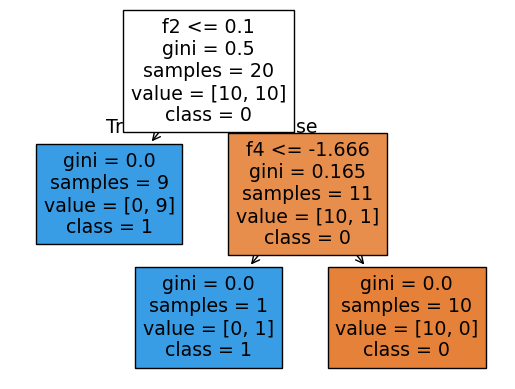

In [14]:
plot_tree(clf1,feature_names=df1.drop('target',axis=1).columns,class_names=['0','1'],filled=True)

[Text(0.6, 0.8333333333333334, 'f2 <= 0.17\ngini = 0.495\nsamples = 20\nvalue = [9, 11]\nclass = 1'),
 Text(0.4, 0.5, 'f3 <= -2.603\ngini = 0.153\nsamples = 12\nvalue = [1, 11]\nclass = 1'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = 0'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]\nclass = 1'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]\nclass = 0'),
 Text(0.7, 0.6666666666666667, '  False')]

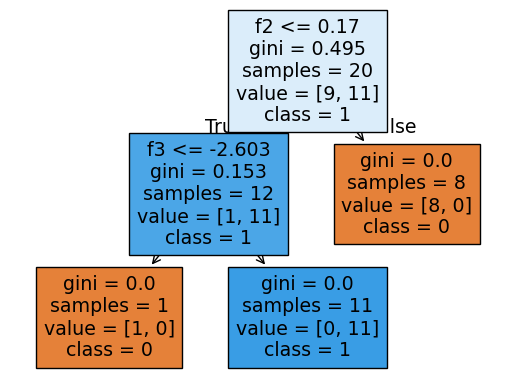

In [15]:
plot_tree(clf2,feature_names=df2.drop('target',axis=1).columns,class_names=['0','1'],filled=True)


[Text(0.6666666666666666, 0.875, 'f3 <= 0.265\ngini = 0.5\nsamples = 20\nvalue = [10, 10]\nclass = 0'),
 Text(0.5, 0.625, 'f2 <= -0.481\ngini = 0.278\nsamples = 12\nvalue = [10, 2]\nclass = 0'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'f5 <= 1.008\ngini = 0.444\nsamples = 3\nvalue = [1, 2]\nclass = 1'),
 Text(0.16666666666666666, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = 1'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = 0'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]\nclass = 0'),
 Text(0.8333333333333334, 0.625, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]\nclass = 1'),
 Text(0.75, 0.75, '  False')]

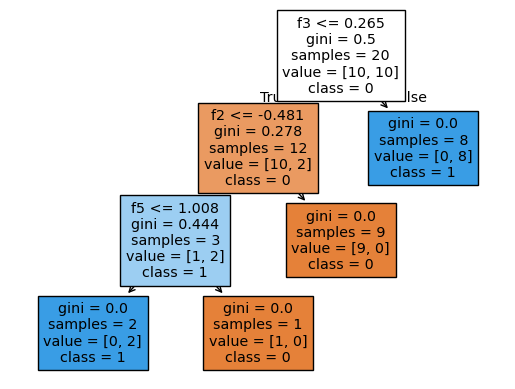

In [16]:
plot_tree(clf3,feature_names=df3.drop('target',axis=1).columns,class_names=['0','1'],filled=True)


Now i want to predict for this line taken from the original dataset already predicted to 1

-0.216385, -1.965156, 2.068944, -1.110243, 1.670610

In [17]:
clf1.predict(np.array([-0.216385, -1.965156, 2.068944, -1.110243,1.670610]).reshape(1,5))

c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [18]:
clf2.predict(np.array([-0.216385, -1.965156, 2.068944, -1.110243,1.670610]).reshape(1,5))

c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [19]:
clf3.predict(np.array([-0.216385, -1.965156, 2.068944, -1.110243,1.670610]).reshape(1,5))

c:\Users\DSingh\miniconda3\envs\ml_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

all 3 models predicted 1 

## Now we are doing with column sampling 

In [25]:
df1=sample_features(df,0.8)
df2=sample_features(df,0.8)
df3=sample_features(df,0.8)

In [26]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [27]:
clf1.fit(df1.iloc[:,0:4],df1['target'])
clf2.fit(df2.iloc[:,0:4],df2['target'])
clf3.fit(df3.iloc[:,0:4],df3['target'])


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

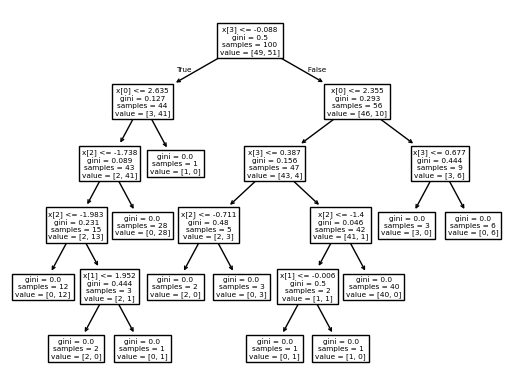

In [36]:
plot_tree(clf1);
plt.show()

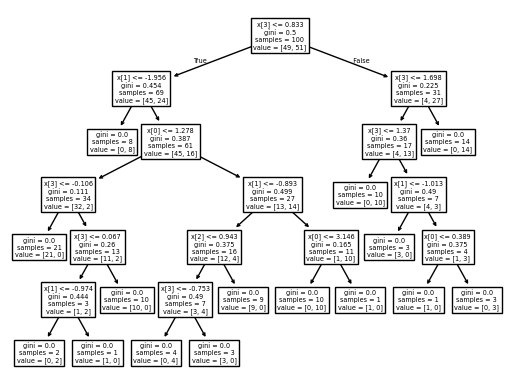

In [37]:
_=plot_tree(clf2);
plt.show()

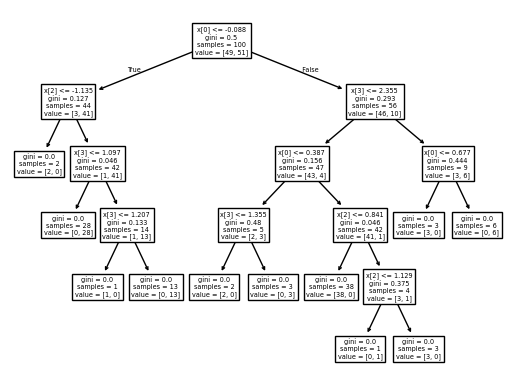

In [38]:
_=plot_tree(clf3);
plt.show()

In [39]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['f1', 'f5', 'f4', 'f2', 'target'], dtype='str')
Index(['f1', 'f4', 'f5', 'f3', 'target'], dtype='str')
Index(['f2', 'f5', 'f3', 'f1', 'target'], dtype='str')
